
# Skin Disease Classification using CNN and with implementation of BoVW

Mounting Drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Loading Dataset

In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/skin-disease-classification.zip"  # change if name is different
extract_path = "/content/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted!")

Dataset extracted!


Dataset Verification

In [ ]:
import os

split_smol_path = "/content/Split_smol"

if os.path.exists(split_smol_path):
    print(f"Contents of '{split_smol_path}':")
    print(os.listdir(split_smol_path))
else:
    print(f"Error: The directory '{split_smol_path}' does not exist.")
    print("This usually means the dataset (skin-disease-classification.zip) has not been unzipped.")
    print("Please run cell 'c1Epb7nezLTy' first to unzip the dataset and create this directory.")

Contents of '/content/Split_smol':
['val', 'train']


CNN Model Training

Found 697 images belonging to 9 classes.
Found 181 images belonging to 9 classes.
Classes: {'Actinic keratosis': 0, 'Atopic Dermatitis': 1, 'Benign keratosis': 2, 'Dermatofibroma': 3, 'Melanocytic nevus': 4, 'Melanoma': 5, 'Squamous cell carcinoma': 6, 'Tinea Ringworm Candidiasis': 7, 'Vascular lesion': 8}
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,113 (9.24 MB)

 Trainable params: 165,129 (645.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.4060 - loss: 1.7357 - val_accuracy: 0.5856 - val_loss: 1.1672
Epoch 2/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.6155 - loss: 1.0761 - val_accuracy: 0.6685 - val_loss: 1.0091
Epoch 3/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.6887 - loss: 0.8641 - val_accuracy: 0.6961 - val_loss: 0.9214
Epoch 4/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.7131 - loss: 0.8028 - val_accuracy: 0.7072 - val_loss: 0.9219
Epoch 5/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.7547 - loss: 0.7055 - val_accuracy: 0.6906 - val_loss: 0.8820
Epoch 6/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.7389 - loss: 0.6821 - val_accuracy: 0.6961 - val_loss: 0.9411
Epoch 7/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.7791 - loss: 0.5982 - val_accuracy: 0.6906 - val_loss: 0.9252
Epoch 8/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.7905 - loss: 0.5763 - val_accuracy: 0.7348 - val_loss:

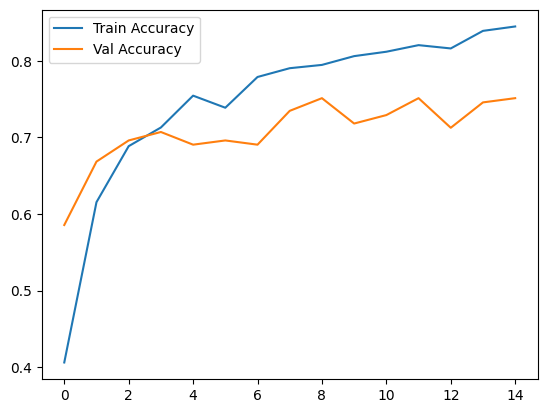

Model saved!


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# =========================
# PATHS
# =========================
TRAIN_DIR = "/content/Split_smol/train"
VAL_DIR = "/content/Split_smol/val"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# =========================
# DATA AUGMENTATION
# =========================
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.2
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse'
)

val_data = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse'
)

print("Classes:", train_data.class_indices)

# =========================
# BASE MODEL (MobileNetV2)
# =========================
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

# =========================
# MODEL BUILD
# =========================
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(train_data.num_classes, activation='softmax')
])

# =========================
# COMPILE
# =========================
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# =========================
# TRAIN
# =========================
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15
)

# =========================
# PLOT
# =========================
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.show()

# =========================
# SAVE MODEL
# =========================
model.save("skin_disease_mobilenet.h5")
print("Model saved!")

Model Loaded

In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model("skin_disease_mobilenet.h5")
print("Model loaded!")

Model loaded!


In [ ]:
class_names = list(train_data.class_indices.keys())
print(class_names)

['Actinic keratosis', 'Atopic Dermatitis', 'Benign keratosis', 'Dermatofibroma', 'Melanocytic nevus', 'Melanoma', 'Squamous cell carcinoma', 'Tinea Ringworm Candidiasis', 'Vascular lesion']


Prediction

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
class_names = sorted(os.listdir("/content/Split_smol/train"))
def predict_with_visual(img_path):
    # load image
    img = image.load_img(img_path, target_size=(224, 224))
    # preprocess
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    # prediction
    prediction = model.predict(img_array)
    predicted_class = class_names[np.argmax(prediction)]
    confidence = np.max(prediction) * 100
    # show image
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{predicted_class} ({confidence:.2f}%)")
    plt.show()
    # print result
    print("🧠 Predicted Class:", predicted_class)
    print("📊 Confidence:", f"{confidence:.2f}%")

Images from training data

In [ ]:
import os

base_path = "/content/Split_smol/train"

for class_name in os.listdir(base_path):
    class_path = os.path.join(base_path, class_name)

    for img_name in os.listdir(class_path)[:2]:  # first 2 images only
        img_path = os.path.join(class_path, img_name)
        print(img_path)

/content/Split_smol/train/Actinic keratosis/ISIC_0027884.jpg
/content/Split_smol/train/Actinic keratosis/ISIC_0030408.jpg
/content/Split_smol/train/Melanocytic nevus/ISIC_0000100_downsampled.jpg
/content/Split_smol/train/Melanocytic nevus/ISIC_0000117_downsampled.jpg
/content/Split_smol/train/Vascular lesion/ISIC_0031996.jpg
/content/Split_smol/train/Vascular lesion/ISIC_0026349.jpg
/content/Split_smol/train/Tinea Ringworm Candidiasis/aug_0_Screenshot 2021-09-14 112859.png
/content/Split_smol/train/Tinea Ringworm Candidiasis/aug_0_B9780702044496000291_f029-001-9780702044496.jpg
/content/Split_smol/train/Melanoma/ISIC_0000141_downsampled.jpg
/content/Split_smol/train/Melanoma/ISIC_0000146_downsampled.jpg
/content/Split_smol/train/Dermatofibroma/ISIC_0029130.jpg
/content/Split_smol/train/Dermatofibroma/ISIC_0025594.jpg
/content/Split_smol/train/Atopic Dermatitis/1_39.jpg
/content/Split_smol/train/Atopic Dermatitis/1_58.jpg
/content/Split_smol/train/Benign keratosis/ISIC_0014652_downsampl

Testing from images of training data

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


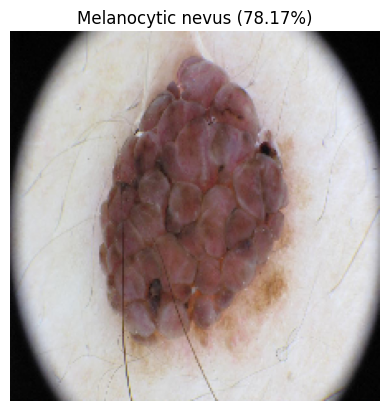

🧠 Predicted Class: Melanocytic nevus
📊 Confidence: 78.17%


In [ ]:
img_path = "/content/Split_smol/train/Melanocytic nevus/ISIC_0000100_downsampled.jpg"
predict_with_visual(img_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


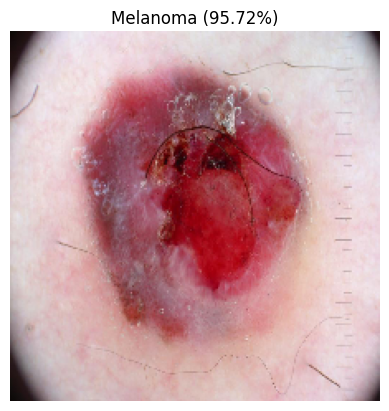

🧠 Predicted Class: Melanoma
📊 Confidence: 95.72%


In [ ]:
img_path = "/content/Split_smol/train/Melanoma/ISIC_0000146_downsampled.jpg"
predict_with_visual(img_path)

Images from Testing Data

In [ ]:
base_path = "/content/Split_smol/val"

for class_name in os.listdir(base_path):
    class_path = os.path.join(base_path, class_name)

    for img_name in os.listdir(class_path)[:2]:
        img_path = os.path.join(class_path, img_name)
        print(img_path)

/content/Split_smol/val/Actinic keratosis/ISIC_0027580.jpg
/content/Split_smol/val/Actinic keratosis/ISIC_0030036.jpg
/content/Split_smol/val/Melanocytic nevus/ISIC_0000071.jpg
/content/Split_smol/val/Melanocytic nevus/ISIC_0000025_downsampled.jpg
/content/Split_smol/val/Vascular lesion/ISIC_0025807.jpg
/content/Split_smol/val/Vascular lesion/ISIC_0028146.jpg
/content/Split_smol/val/Tinea Ringworm Candidiasis/aug_0_B9780702044496000291_f029-001-9780702044496-1.jpg
/content/Split_smol/val/Tinea Ringworm Candidiasis/aug_0_pha-259018.jpg
/content/Split_smol/val/Melanoma/ISIC_0011135.jpg
/content/Split_smol/val/Melanoma/ISIC_0001100_downsampled.jpg
/content/Split_smol/val/Dermatofibroma/ISIC_0029760.jpg
/content/Split_smol/val/Dermatofibroma/ISIC_0031443.jpg
/content/Split_smol/val/Atopic Dermatitis/1_39.jpg
/content/Split_smol/val/Atopic Dermatitis/1_26.jpg
/content/Split_smol/val/Benign keratosis/ISIC_0015260_downsampled.jpg
/content/Split_smol/val/Benign keratosis/ISIC_0014603_downsampl

Testing images from testing data

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


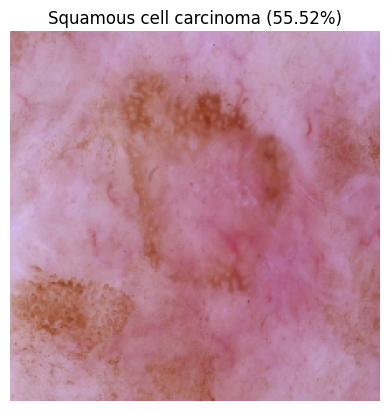

🧠 Predicted Class: Squamous cell carcinoma
📊 Confidence: 55.52%


In [ ]:
img_path = "/content/Split_smol/val/Squamous cell carcinoma/ISIC_0025712.jpg"
predict_with_visual(img_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


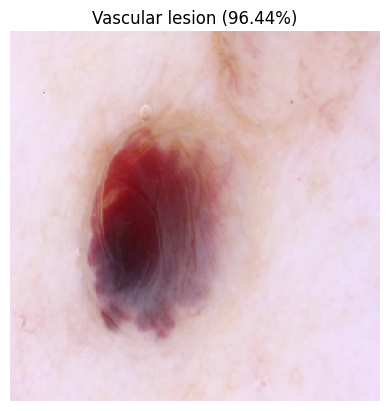

🧠 Predicted Class: Vascular lesion
📊 Confidence: 96.44%


In [ ]:
img_path = "/content/Split_smol/val/Vascular lesion/ISIC_0028146.jpg"
predict_with_visual(img_path)

BoVW Implementation

In [ ]:
# In a new cell, run this to check your path
import os
print(os.listdir("/content/Split_smol/train"))

['Actinic keratosis', 'Melanocytic nevus', 'Vascular lesion', 'Tinea Ringworm Candidiasis', 'Melanoma', 'Dermatofibroma', 'Atopic Dermatitis', 'Benign keratosis', 'Squamous cell carcinoma']



📂 LOADING DATASET
📁 Loaded 697 images from 9 classes
   - Actinic keratosis: 80 images
   - Atopic Dermatitis: 81 images
   - Benign keratosis: 80 images
   - Dermatofibroma: 80 images
   - Melanocytic nevus: 80 images
   - Melanoma: 80 images
   - Squamous cell carcinoma: 80 images
   - Tinea Ringworm Candidiasis: 56 images
   - Vascular lesion: 80 images

📊 Split: 557 train, 140 test

🚀 STARTING TRAINING
📚 Building visual dictionary...


Extracting features: 100%|██████████| 557/557 [05:58<00:00,  1.56it/s]


🔄 Clustering 35648 features into 1200 words...
✅ Dictionary built!
📊 Computing histograms...


Computing BoVW: 100%|██████████| 557/557 [05:53<00:00,  1.57it/s]


🎯 Training SVM classifier...
✅ Training complete!


📊 EVALUATION RESULTS

✅ Accuracy: 72.86%

📈 Classification Report:
                            precision    recall  f1-score   support

         Actinic keratosis       0.84      0.73      0.78        22
         Atopic Dermatitis       0.58      0.78      0.67        18
          Benign keratosis       0.86      0.75      0.80        16
            Dermatofibroma       0.55      0.73      0.63        15
         Melanocytic nevus       0.80      0.60      0.69        20
                  Melanoma       0.80      0.67      0.73        12
   Squamous cell carcinoma       0.67      0.78      0.72        18
Tinea Ringworm Candidiasis       0.83      0.83      0.83         6
           Vascular lesion       0.91      0.77      0.83        13

                  accuracy                           0.73       140
                 macro avg       0.76      0.74      0.74       140
              weighted avg       0.75      0.73      0.73      

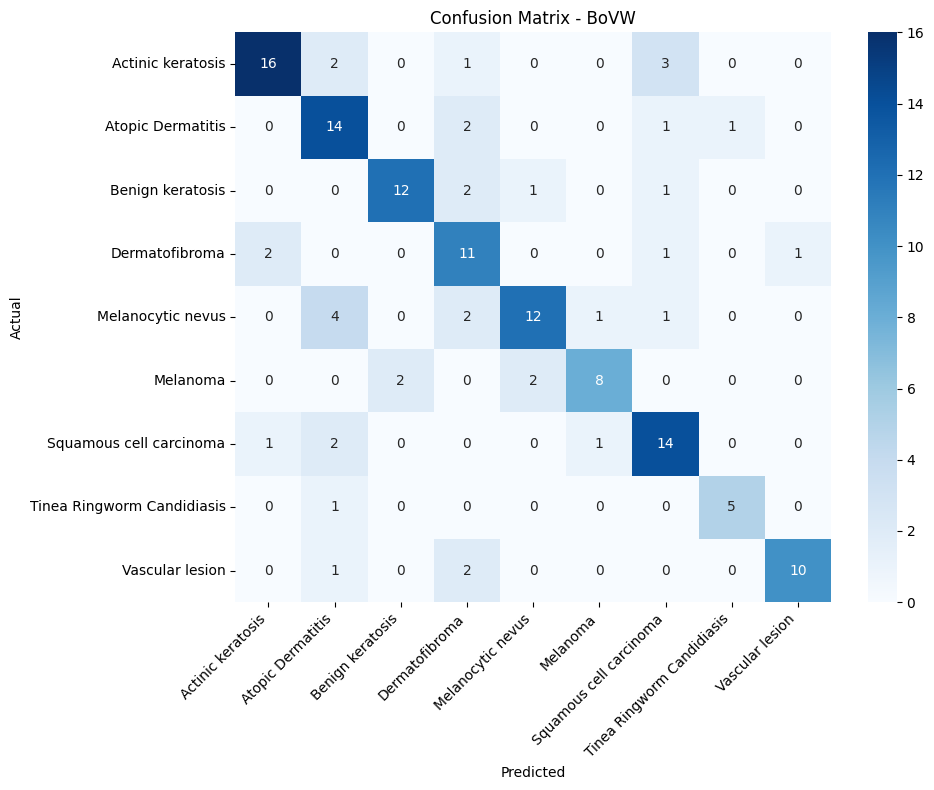


📊 PER-CLASS ACCURACY
Actinic keratosis             : 72.7% (16/22)
Atopic Dermatitis             : 77.8% (14/18)
Benign keratosis              : 75.0% (12/16)
Dermatofibroma                : 73.3% (11/15)
Melanocytic nevus             : 60.0% (12/20)
Melanoma                      : 66.7% (8/12)
Squamous cell carcinoma       : 77.8% (14/18)
Tinea Ringworm Candidiasis    : 83.3% (5/6)
Vascular lesion               : 76.9% (10/13)
💾 Model saved to skin_bovw_final.pkl

🔮 EXAMPLE PREDICTION

📷 Image: 2_2.jpg
🎯 True: Atopic Dermatitis
🤖 Predicted: Atopic Dermatitis
📊 Confidence: 48.93%

🏆 Top 3 Predictions:
   Tinea Ringworm Candidiasis: 48.9%
   Atopic Dermatitis: 27.6%
   Benign keratosis: 7.9%


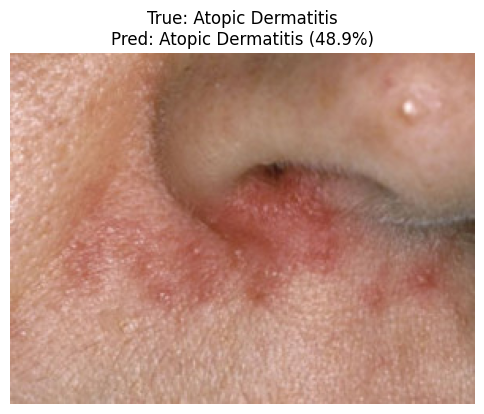

In [ ]:
"""
Bag of Visual Words (BoVW) for Skin Disease Classification
"""

import numpy as np
import cv2
import os
from sklearn.cluster import MiniBatchKMeans
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tqdm import tqdm
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================
# 1. BAG OF VISUAL WORDS CLASS (OPTIMIZED)
# ============================================

class BagOfVisualWords:
    def __init__(self, n_clusters=1200, patch_size=(48, 48), stride=24):
        """
        Initialize BoVW classifier - OPTIMIZED for 8 skin disease classes

        Args:
            n_clusters: 1200 visual words (optimal for 8 classes)
            patch_size: 48x48 (captures lesion patterns better)
            stride: 24 (50% overlap)
        """
        self.n_clusters = n_clusters
        self.patch_size = patch_size
        self.stride = stride

        # CNN feature extractor (frozen ResNet50)
        self.cnn = ResNet50(weights='imagenet', include_top=False, pooling='avg')

        # BoVW components
        self.kmeans = None
        self.scaler = StandardScaler()

        # RBF Kernel for complex skin disease patterns
        self.svm = SVC(kernel='rbf', C=10, gamma='scale',
                       class_weight='balanced', probability=True)

    def extract_patches(self, image_path):
        """Extract dense patches from image"""
        img = load_img(image_path, target_size=(224, 224))
        img_array = img_to_array(img)

        h, w = img_array.shape[:2]
        ph, pw = self.patch_size

        patches = []
        for y in range(0, h - ph + 1, self.stride):
            for x in range(0, w - pw + 1, self.stride):
                patch = img_array[y:y+ph, x:x+pw]
                patches.append(patch)

        return np.array(patches)

    def extract_features(self, patches):
        """Extract CNN features from patches"""
        if len(patches) == 0:
            return np.array([])

        patches = preprocess_input(patches.astype(np.float32))
        features = self.cnn.predict(patches, verbose=0)
        return features

    def build_dictionary(self, image_paths, max_features=50000):
        """Build visual vocabulary using K-means"""
        print("📚 Building visual dictionary...")

        all_features = []

        for img_path in tqdm(image_paths, desc="Extracting features"):
            patches = self.extract_patches(img_path)
            if len(patches) > 0:
                features = self.extract_features(patches)
                all_features.extend(features)

        all_features = np.array(all_features)

        if len(all_features) > max_features:
            idx = np.random.choice(len(all_features), max_features, replace=False)
            all_features = all_features[idx]

        print(f"🔄 Clustering {len(all_features)} features into {self.n_clusters} words...")
        self.kmeans = MiniBatchKMeans(
            n_clusters=self.n_clusters,
            batch_size=1000,
            random_state=42,
            verbose=0
        )
        self.kmeans.fit(all_features)
        print("✅ Dictionary built!")

    def compute_histogram(self, image_path):
        """Compute BoVW histogram for an image"""
        patches = self.extract_patches(image_path)
        if len(patches) == 0:
            return np.zeros(self.n_clusters)

        features = self.extract_features(patches)
        words = self.kmeans.predict(features)

        hist = np.zeros(self.n_clusters)
        for word in words:
            hist[word] += 1

        # Normalize
        hist = hist / (hist.sum() + 1e-6)

        return hist

    def prepare_features(self, image_paths, labels):
        """Prepare features for all images"""
        print("📊 Computing histograms...")

        histograms = []
        for img_path in tqdm(image_paths, desc="Computing BoVW"):
            hist = self.compute_histogram(img_path)
            histograms.append(hist)

        X = np.array(histograms)
        y = np.array(labels)

        X = self.scaler.fit_transform(X)

        return X, y

    def train(self, train_images, train_labels):
        """Train the complete BoVW pipeline"""
        print("\n" + "="*50)
        print("🚀 STARTING TRAINING")
        print("="*50)

        self.build_dictionary(train_images)
        X_train, y_train = self.prepare_features(train_images, train_labels)

        print("🎯 Training SVM classifier...")
        self.svm.fit(X_train, y_train)

        print("✅ Training complete!")
        print("="*50 + "\n")

    def predict(self, image_paths):
        """Predict classes for images"""
        histograms = []
        for img_path in image_paths:
            hist = self.compute_histogram(img_path)
            histograms.append(hist)

        X = np.array(histograms)
        X = self.scaler.transform(X)

        return self.svm.predict(X)

    def predict_proba(self, image_paths):
        """Get prediction probabilities"""
        histograms = []
        for img_path in image_paths:
            hist = self.compute_histogram(img_path)
            histograms.append(hist)

        X = np.array(histograms)
        X = self.scaler.transform(X)

        return self.svm.predict_proba(X)

    def evaluate(self, test_images, test_labels, class_names=None):
        """Evaluate model performance"""
        print("\n" + "="*50)
        print("📊 EVALUATION RESULTS")
        print("="*50)

        predictions = self.predict(test_images)
        accuracy = accuracy_score(test_labels, predictions)

        print(f"\n✅ Accuracy: {accuracy*100:.2f}%")

        print("\n📈 Classification Report:")
        print(classification_report(test_labels, predictions, target_names=class_names))

        # Confusion Matrix
        cm = confusion_matrix(test_labels, predictions)
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names)
        plt.title('Confusion Matrix - BoVW')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

        return accuracy

    def save_model(self, path):
        """Save model to disk"""
        with open(path, 'wb') as f:
            pickle.dump({
                'kmeans': self.kmeans,
                'scaler': self.scaler,
                'svm': self.svm,
                'n_clusters': self.n_clusters,
                'patch_size': self.patch_size,
                'stride': self.stride
            }, f)
        print(f"💾 Model saved to {path}")

    def load_model(self, path):
        """Load model from disk"""
        with open(path, 'rb') as f:
            data = pickle.load(f)
            self.kmeans = data['kmeans']
            self.scaler = data['scaler']
            self.svm = data['svm']
            self.n_clusters = data['n_clusters']
            self.patch_size = data['patch_size']
            self.stride = data['stride']
        print(f"📂 Model loaded from {path}")

# ============================================
# 2. DATA LOADING
# ============================================

def load_dataset(data_dir):
    """Load dataset from folder structure"""
    images = []
    labels = []
    class_names = []

    for class_idx, class_name in enumerate(sorted(os.listdir(data_dir))):
        class_path = os.path.join(data_dir, class_name)

        if not os.path.isdir(class_path):
            continue

        class_names.append(class_name)
        image_files = [f for f in os.listdir(class_path)
                      if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        for img_file in image_files:
            img_path = os.path.join(class_path, img_file)
            images.append(img_path)
            labels.append(class_idx)

    print(f"📁 Loaded {len(images)} images from {len(class_names)} classes")
    for i, name in enumerate(class_names):
        count = labels.count(i)
        print(f"   - {name}: {count} images")

    return images, labels, class_names

# ============================================
# 3. MAIN FUNCTION - READY TO RUN
# ============================================

def main():
    # ===== CONFIGURATION =====
    DATA_DIR = "/content/Split_smol/train"  # CHANGE THIS TO YOUR PATH
    TEST_SIZE = 0.2
    RANDOM_STATE = 42

    # OPTIMIZED for 8 classes
    N_CLUSTERS = 1200      # Visual vocabulary size
    PATCH_SIZE = (48, 48)  # Patch dimensions
    STRIDE = 24            # Patch stride

    # ===== LOAD DATA =====
    print("\n" + "="*50)
    print("📂 LOADING DATASET")
    print("="*50)

    images, labels, class_names = load_dataset(DATA_DIR)

    if len(images) == 0:
        print("❌ ERROR: No images found! Check your path.")
        return

    # ===== SPLIT DATA =====
    X_train, X_test, y_train, y_test = train_test_split(
        images, labels,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE
    )

    print(f"\n📊 Split: {len(X_train)} train, {len(X_test)} test")

    # ===== TRAIN MODEL =====
    bovw = BagOfVisualWords(
        n_clusters=N_CLUSTERS,
        patch_size=PATCH_SIZE,
        stride=STRIDE
    )

    bovw.train(X_train, y_train)

    # ===== EVALUATE =====
    accuracy = bovw.evaluate(X_test, y_test, class_names)

    # ===== PER-CLASS ACCURACY =====
    print("\n" + "="*50)
    print("📊 PER-CLASS ACCURACY")
    print("="*50)

    predictions = bovw.predict(X_test)
    for i, class_name in enumerate(class_names):
        class_indices = [idx for idx, label in enumerate(y_test) if label == i]
        if len(class_indices) > 0:
            correct = sum(1 for idx in class_indices if predictions[idx] == i)
            class_acc = correct / len(class_indices)
            print(f"{class_name:30s}: {class_acc*100:.1f}% ({correct}/{len(class_indices)})")

    # ===== SAVE MODEL =====
    bovw.save_model("skin_bovw_final.pkl")

    # ===== EXAMPLE PREDICTION =====
    print("\n" + "="*50)
    print("🔮 EXAMPLE PREDICTION")
    print("="*50)

    test_img = X_test[0]
    true_label = class_names[y_test[0]]
    pred_idx = bovw.predict([test_img])[0]
    pred_label = class_names[pred_idx]
    proba = bovw.predict_proba([test_img])[0]

    print(f"\n📷 Image: {os.path.basename(test_img)}")
    print(f"🎯 True: {true_label}")
    print(f"🤖 Predicted: {pred_label}")
    print(f"📊 Confidence: {max(proba)*100:.2f}%")

    # Show top 3 predictions
    top3_idx = np.argsort(proba)[-3:][::-1]
    print("\n🏆 Top 3 Predictions:")
    for idx in top3_idx:
        print(f"   {class_names[idx]}: {proba[idx]*100:.1f}%")

    # Display image
    img = cv2.imread(test_img)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"True: {true_label}\nPred: {pred_label} ({max(proba)*100:.1f}%)")
    plt.axis("off")
    plt.show()

# ============================================
# 4. RUN
# ============================================

if __name__ == "__main__":
    main()

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# =========================
# LOAD CIFAR-10 DATASET
# =========================
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Resize images from 32x32 to 224x224
x_train = tf.image.resize(x_train, (224, 224))
x_test = tf.image.resize(x_test, (224, 224))

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# One-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# =========================
# VGG16 MODEL
# =========================
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

# =========================
# BUILD MODEL
# =========================
model = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

# =========================
# COMPILE
# =========================
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# =========================
# TRAIN
# =========================
history = model.fit(
    x_train,
    y_train,
    validation_data=(x_test, y_test),
    epochs=10,
    batch_size=32
)

# =========================
# EVALUATE
# =========================
loss, accuracy = model.evaluate(x_test, y_test)

print(f"\nTest Accuracy: {accuracy*100:.2f}%")

# =========================
# PLOT ACCURACY
# =========================
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('VGG16 on CIFAR-10')
plt.legend()
plt.show()

# =========================
# SAVE MODEL
# =========================
model.save("vgg16_cifar10.keras")

print("✅ Model Saved Successfully")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
